In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
import os
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import math
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    precision_score,
    recall_score,
    f1_score
)

from joblib import dump
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from joblib import load
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.metrics import roc_auc_score
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [5]:
df = pd.read_csv(r"D:\IPP_study\Machinelearning\project\criteo-uplift-v2.1.csv")

print(df.head())
print(df.shape)

          f0         f1        f2        f3         f4        f5        f6  \
0  12.616365  10.059654  8.976429  4.679882  10.280525  4.115453  0.294443   
1  12.616365  10.059654  9.002689  4.679882  10.280525  4.115453  0.294443   
2  12.616365  10.059654  8.964775  4.679882  10.280525  4.115453  0.294443   
3  12.616365  10.059654  9.002801  4.679882  10.280525  4.115453  0.294443   
4  12.616365  10.059654  9.037999  4.679882  10.280525  4.115453  0.294443   

         f7        f8         f9       f10       f11  treatment  conversion  \
0  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   
1  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   
2  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   
3  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   
4  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   

   visit  exposure  
0      0         0  
1      0      

In [6]:
# test set
# Fixed random seed for reproducibility
random_state = 42

# Split by treatment
df_t0 = df[df["treatment"] == 0]
df_t1 = df[df["treatment"] == 1]

# Randomly sample 1/5 as test set for each group
test_t0 = df_t0.sample(frac=0.2, random_state=random_state)
test_t1 = df_t1.sample(frac=0.2, random_state=random_state)

# Create output directory if it does not exist
output_dir = r"D:\IPP_study\Machinelearning\project\fulldatatestset"
os.makedirs(output_dir, exist_ok=True)

# Save test sets
path_t0 = os.path.join(output_dir, "test_treatment_0.csv")
path_t1 = os.path.join(output_dir, "test_treatment_1.csv")

test_t0.to_csv(path_t0, index=False)
test_t1.to_csv(path_t1, index=False)

# Print dataset info
print(f"Test set for treatment=0 saved to: {path_t0}")
print(f"Test set for treatment=1 saved to: {path_t1}")

print(f"Test set shape (treatment=0): {test_t0.shape}")
print(f"Test set shape (treatment=1): {test_t1.shape}")

# Conversion rate (conversion == 1)
conversion_rate_t0 = test_t0["conversion"].mean()
conversion_rate_t1 = test_t1["conversion"].mean()

print(f"Conversion rate for treatment=0 (conversion=1): {conversion_rate_t0:.6f}")
print(f"Conversion rate for treatment=1 (conversion=1): {conversion_rate_t1:.6f}")

Test set for treatment=0 saved to: D:\IPP_study\Machinelearning\project\fulldatatestset\test_treatment_0.csv
Test set for treatment=1 saved to: D:\IPP_study\Machinelearning\project\fulldatatestset\test_treatment_1.csv
Test set shape (treatment=0): (419387, 16)
Test set shape (treatment=1): (2376531, 16)
Conversion rate for treatment=0 (conversion=1): 0.002010
Conversion rate for treatment=1 (conversion=1): 0.003099


In [7]:
# Remove test samples to create training sets
train_t0 = df_t0.drop(index=test_t0.index)
train_t1 = df_t1.drop(index=test_t1.index)

# Create output directory if it does not exist
output_dir = r"D:\IPP_study\Machinelearning\project\fulldatatrainingset"
os.makedirs(output_dir, exist_ok=True)

# Save training sets
path_train_t0 = os.path.join(output_dir, "train_treatment_0.csv")
path_train_t1 = os.path.join(output_dir, "train_treatment_1.csv")

train_t0.to_csv(path_train_t0, index=False)
train_t1.to_csv(path_train_t1, index=False)

# Print dataset info
print(f"Training set for treatment=0 saved to: {path_train_t0}")
print(f"Training set shape (treatment=0): {train_t0.shape}")

print(f"Training set for treatment=1 saved to: {path_train_t1}")
print(f"Training set shape (treatment=1): {train_t1.shape}")

Training set for treatment=0 saved to: D:\IPP_study\Machinelearning\project\fulldatatrainingset\train_treatment_0.csv
Training set shape (treatment=0): (1677550, 16)
Training set for treatment=1 saved to: D:\IPP_study\Machinelearning\project\fulldatatrainingset\train_treatment_1.csv
Training set shape (treatment=1): (9506124, 16)


In [7]:
# training
# Paths
DATA_PATH_T0 = r"D:\IPP_study\Machinelearning\project\fulldatatrainingset\train_treatment_0.csv"
DATA_PATH_T1 = r"D:\IPP_study\Machinelearning\project\fulldatatrainingset\train_treatment_1.csv"

MODEL_DIR = r"D:\IPP_study\Machinelearning\project\fulldatamodel"
os.makedirs(MODEL_DIR, exist_ok=True)

# Common settings
feature_cols = [f"f{i}" for i in range(12)]
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

def cv_and_train_full(data_path, treatment_label):
    print(f"\n======================================")
    print(f"Cross-validation for treatment={treatment_label}")
    print(f"======================================")

    # Load data
    df = pd.read_csv(data_path)

    X = df[feature_cols].values
    y = df["conversion"].values

    auc_scores = []

    # K-Fold Cross Validation
    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        print(f"\n========== Fold {fold}/{K} ==========")

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Scaling (fit on train only)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        # Logistic Regression 
        model = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs"
        )

        model.fit(X_train_scaled, y_train)
        val_pred = model.predict_proba(X_val_scaled)[:, 1]

        auc = roc_auc_score(y_val, val_pred)
        auc_scores.append(auc)

        print(f"Fold {fold} AUC: {auc:.4f}")

    # CV Summary
    mean_auc = np.mean(auc_scores)
    std_auc = np.std(auc_scores)

    print("\n========== CV Summary ==========")
    print(f"Mean AUC: {mean_auc:.4f}")
    print(f"Std  AUC: {std_auc:.4f}")

    # Train final model on FULL dataset
    print("\nTraining final model on full training dataset...")

    final_scaler = StandardScaler()
    X_scaled_full = final_scaler.fit_transform(X)

    final_model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    )

    final_model.fit(X_scaled_full, y)

    # Save final model
    model_path = os.path.join(
        MODEL_DIR,
        f"logreg_treatment{treatment_label}_final.joblib"
    )
    scaler_path = os.path.join(
        MODEL_DIR,
        f"scaler_treatment{treatment_label}_final.joblib"
    )

    joblib.dump(final_model, model_path)
    joblib.dump(final_scaler, scaler_path)

    print(f"\nFinal model saved to:  {model_path}")
    print(f"Final scaler saved to: {scaler_path}")

# Run for treatment=0
cv_and_train_full(DATA_PATH_T0, treatment_label=0)

# Run for treatment=1
cv_and_train_full(DATA_PATH_T1, treatment_label=1)

print("\n✅ All final models trained on full datasets and saved successfully.")


Cross-validation for treatment=0

========== Fold 1/5 ==========
Fold 1 AUC: 0.9487

========== Fold 2/5 ==========
Fold 2 AUC: 0.9593

========== Fold 3/5 ==========
Fold 3 AUC: 0.9563

========== Fold 4/5 ==========
Fold 4 AUC: 0.9583

========== Fold 5/5 ==========
Fold 5 AUC: 0.9540

========== CV Summary ==========
Mean AUC: 0.9553
Std  AUC: 0.0038

Training final model on full training dataset...

Final model saved to:  D:\IPP_study\Machinelearning\project\fulldatamodel\logreg_treatment0_final.joblib
Final scaler saved to: D:\IPP_study\Machinelearning\project\fulldatamodel\scaler_treatment0_final.joblib

Cross-validation for treatment=1

========== Fold 1/5 ==========
Fold 1 AUC: 0.9526

========== Fold 2/5 ==========
Fold 2 AUC: 0.9525

========== Fold 3/5 ==========
Fold 3 AUC: 0.9516

========== Fold 4/5 ==========
Fold 4 AUC: 0.9525

========== Fold 5/5 ==========
Fold 5 AUC: 0.9509

========== CV Summary ==========
Mean AUC: 0.9520
Std  AUC: 0.0007

Training final model on 

In [9]:
from sklearn.metrics import accuracy_score

In [11]:
# Evaluation
def evaluate_model(y_true, y_prob, threshold=0.5, title_suffix=""):
    y_pred = (y_prob >= threshold).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)

    print(f"\n========== Test Set Evaluation {title_suffix} ==========")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve {title_suffix}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Proportion")

    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{labels[i][j]}\n{cm[i, j]:,}\n({cm_norm[i, j]*100:.2f}%)",
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold"
            )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Negative", "Pred Positive"])
    ax.set_yticklabels(["Actual Negative", "Actual Positive"])
    ax.set_title("Confusion Matrix (Row-normalized)")
    plt.tight_layout()
    plt.show()


# Paths
TEST_PATH_T0 = r"D:\IPP_study\Machinelearning\project\fulldatatestset\test_treatment_0.csv"
TEST_PATH_T1 = r"D:\IPP_study\Machinelearning\project\fulldatatestset\test_treatment_1.csv"

MODEL_DIR = r"D:\IPP_study\Machinelearning\project\fulldatamodel"

MODEL_T0 = os.path.join(MODEL_DIR, "logreg_treatment0_final.joblib")
SCALER_T0 = os.path.join(MODEL_DIR, "scaler_treatment0_final.joblib")

MODEL_T1 = os.path.join(MODEL_DIR, "logreg_treatment1_final.joblib")
SCALER_T1 = os.path.join(MODEL_DIR, "scaler_treatment1_final.joblib")

# Features
feature_cols = [f"f{i}" for i in range(12)]

# Load test data
df_test_t0 = pd.read_csv(TEST_PATH_T0)
df_test_t1 = pd.read_csv(TEST_PATH_T1)

X_test_t0 = df_test_t0[feature_cols].values
y_test_t0 = df_test_t0["conversion"].values

X_test_t1 = df_test_t1[feature_cols].values
y_test_t1 = df_test_t1["conversion"].values

# Load models & scalers
model_t0 = joblib.load(MODEL_T0)
scaler_t0 = joblib.load(SCALER_T0)

model_t1 = joblib.load(MODEL_T1)
scaler_t1 = joblib.load(SCALER_T1)

# Predict probabilities
X_test_t0_scaled = scaler_t0.transform(X_test_t0)
y_prob_t0 = model_t0.predict_proba(X_test_t0_scaled)[:, 1]

X_test_t1_scaled = scaler_t1.transform(X_test_t1)
y_prob_t1 = model_t1.predict_proba(X_test_t1_scaled)[:, 1]


========== Test Set Evaluation (Treatment = 0) ==========
Accuracy : 0.9158
Precision: 0.0201
Recall   : 0.8553
F1-score : 0.0392
ROC-AUC  : 0.9528


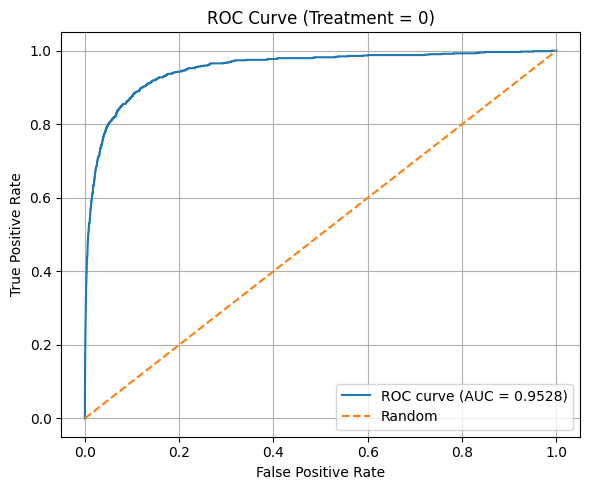

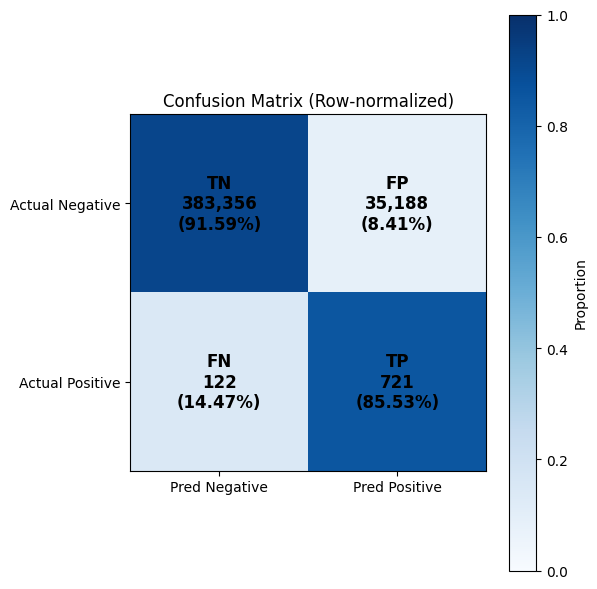

In [12]:
# Evaluation treatment=0
evaluate_model(
    y_true=y_test_t0,
    y_prob=y_prob_t0,
    threshold=0.5,
    title_suffix="(Treatment = 0)"
)


========== Test Set Evaluation (Treatment = 1) ==========
Accuracy : 0.9098
Precision: 0.0290
Recall   : 0.8646
F1-score : 0.0561
ROC-AUC  : 0.9529


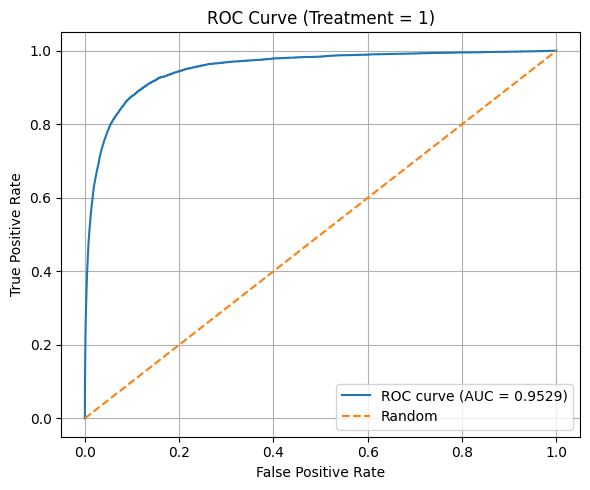

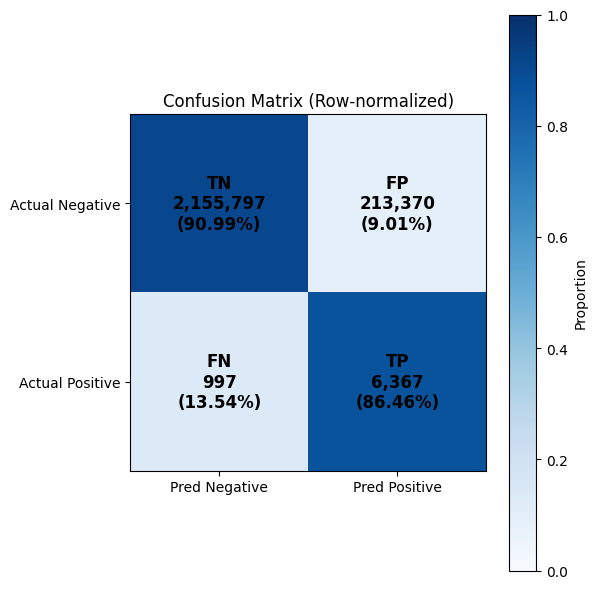

In [13]:
# Evaluation treatment=1
evaluate_model(
    y_true=y_test_t1,
    y_prob=y_prob_t1,
    threshold=0.5,
    title_suffix="(Treatment = 1)"
)

In [14]:
# Youden's J threshold finder
def find_best_threshold_youden(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    return thresholds[best_idx]

# Paths
TEST_T0 = r"D:\IPP_study\Machinelearning\project\fulldatatestset\test_treatment_0.csv"
TEST_T1 = r"D:\IPP_study\Machinelearning\project\fulldatatestset\test_treatment_1.csv"

MODEL_DIR = r"D:\IPP_study\Machinelearning\project\fulldatamodel"

MODEL_T0 = os.path.join(MODEL_DIR, "logreg_treatment0_final.joblib")
SCALER_T0 = os.path.join(MODEL_DIR, "scaler_treatment0_final.joblib")

MODEL_T1 = os.path.join(MODEL_DIR, "logreg_treatment1_final.joblib")
SCALER_T1 = os.path.join(MODEL_DIR, "scaler_treatment1_final.joblib")

feature_cols = [f"f{i}" for i in range(12)]

# Load data
df_t0 = pd.read_csv(TEST_T0)
df_t1 = pd.read_csv(TEST_T1)

X_t0 = df_t0[feature_cols].values
y_t0 = df_t0["conversion"].values

X_t1 = df_t1[feature_cols].values
y_t1 = df_t1["conversion"].values

# Load models
model_t0 = joblib.load(MODEL_T0)
scaler_t0 = joblib.load(SCALER_T0)

model_t1 = joblib.load(MODEL_T1)
scaler_t1 = joblib.load(SCALER_T1)

# Predict probabilities
p_t0 = model_t0.predict_proba(scaler_t0.transform(X_t0))[:, 1]
p_t1 = model_t1.predict_proba(scaler_t1.transform(X_t1))[:, 1]

# Find best thresholds (Youden's J)
best_thr_t0 = find_best_threshold_youden(y_t0, p_t0)
best_thr_t1 = find_best_threshold_youden(y_t1, p_t1)

print(f"\nBest threshold (Treatment=0, Youden J): {best_thr_t0:.4f}")
print(f"Best threshold (Treatment=1, Youden J): {best_thr_t1:.4f}")


Best threshold (Treatment=0, Youden J): 0.3608
Best threshold (Treatment=1, Youden J): 0.4013



========== Test Set Evaluation (Treatment = 0, Optimal Threshold) ==========
Accuracy : 0.8826
Precision: 0.0152
Recall   : 0.8980
F1-score : 0.0298
ROC-AUC  : 0.9528


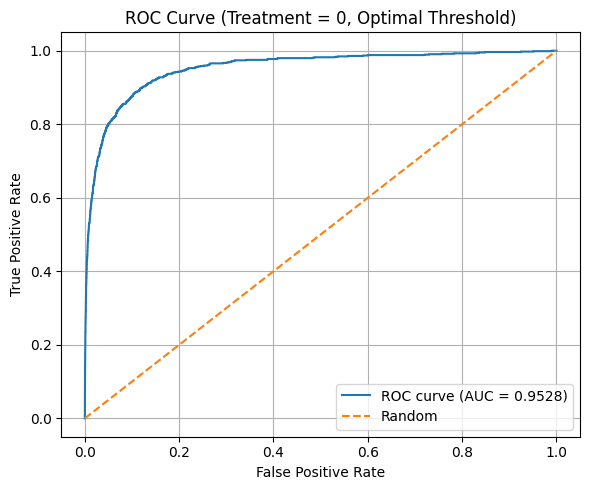

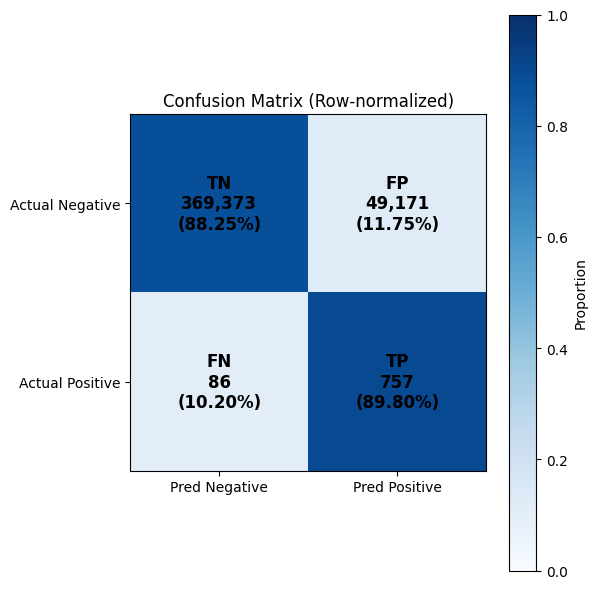

In [15]:
# Final evaluation with optimal thresholds treatment=0
evaluate_model(
    y_true=y_t0,
    y_prob=p_t0,
    threshold=best_thr_t0,
    title_suffix="(Treatment = 0, Optimal Threshold)"
)


========== Test Set Evaluation (Treatment = 1, Optimal Threshold) ==========
Accuracy : 0.8867
Precision: 0.0238
Recall   : 0.8908
F1-score : 0.0464
ROC-AUC  : 0.9529


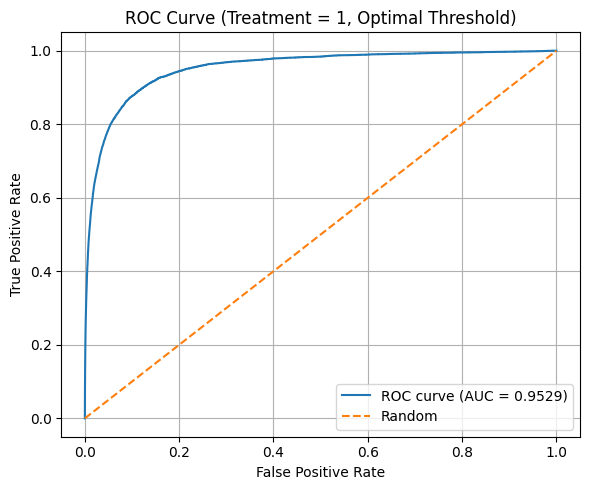

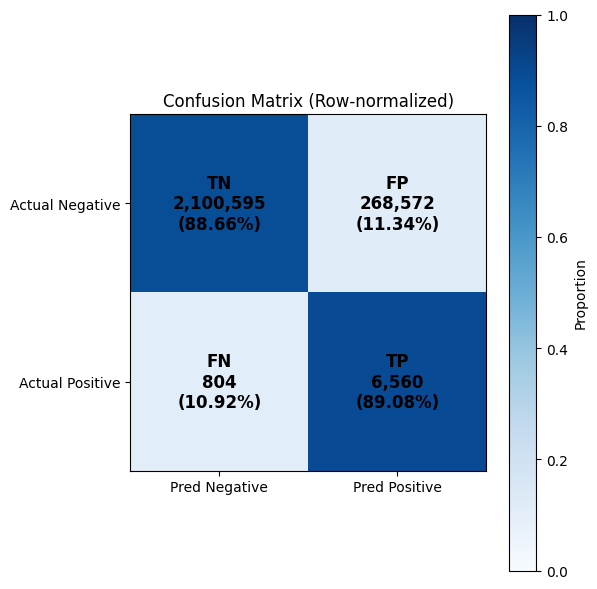

In [16]:
# Final evaluation with optimal thresholds treatment=1
evaluate_model(
    y_true=y_t1,
    y_prob=p_t1,
    threshold=best_thr_t1,
    title_suffix="(Treatment = 1, Optimal Threshold)"
)

In [17]:
# up-lifting calculation
BASE_DIR = r"D:\IPP_study\Machinelearning\project"

TEST_DIR = os.path.join(BASE_DIR, "fulldatatestset")
MODEL_DIR = os.path.join(BASE_DIR, "fulldatamodel")
OUT_DIR = os.path.join(BASE_DIR, "fulldatatestset")

os.makedirs(OUT_DIR, exist_ok=True)

# Test CSVs
TEST_T0 = os.path.join(TEST_DIR, "test_treatment_0.csv")
TEST_T1 = os.path.join(TEST_DIR, "test_treatment_1.csv")

# Output CSV
OUT_PATH = os.path.join(OUT_DIR, "uplift_test_merged_12features.csv")

# Load and merge test data
df_t0 = pd.read_csv(TEST_T0)
df_t1 = pd.read_csv(TEST_T1)

df_all = pd.concat([df_t0, df_t1], axis=0, ignore_index=True)
df_all = df_all.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("Mixed test set shape:", df_all.shape)

# Load final models & scalers
model_t1 = joblib.load(
    os.path.join(MODEL_DIR, "logreg_treatment1_final.joblib")
)
scaler_t1 = joblib.load(
    os.path.join(MODEL_DIR, "scaler_treatment1_final.joblib")
)

model_t0 = joblib.load(
    os.path.join(MODEL_DIR, "logreg_treatment0_final.joblib")
)
scaler_t0 = joblib.load(
    os.path.join(MODEL_DIR, "scaler_treatment0_final.joblib")
)

print("✅ Models and scalers loaded successfully.")

# Construct common feature matrix X
feature_cols = [f"f{i}" for i in range(12)]
X = df_all[feature_cols].values

print("X shape:", X.shape)  # (N, 12)

# Scaling
X_t1_scaled = scaler_t1.transform(X)
X_t0_scaled = scaler_t0.transform(X)

# Predict potential outcomes
p_t1 = model_t1.predict_proba(X_t1_scaled)[:, 1]
p_t0 = model_t0.predict_proba(X_t0_scaled)[:, 1]

# Compute uplift
uplift = p_t1 - p_t0

# Save uplift results
uplift_df = df_all.copy()

uplift_df["p_treatment_1"] = p_t1
uplift_df["p_treatment_0"] = p_t0
uplift_df["uplift"] = uplift
uplift_df["recommend_treatment"] = uplift_df["uplift"] > 0

uplift_df["uplift_decile"] = pd.qcut(
    uplift_df["uplift"],
    q=10,
    labels=False
)

uplift_df.to_csv(OUT_PATH, index=False)

print("\n✅ Uplift calculation finished.")
print("Saved to:", OUT_PATH)

# Summary statistics
print("\nUplift summary:")
print(uplift_df["uplift"].describe())

print("\nMean uplift by decile:")
print(uplift_df.groupby("uplift_decile")["uplift"].mean())

Mixed test set shape: (2795918, 16)
✅ Models and scalers loaded successfully.
X shape: (2795918, 12)

✅ Uplift calculation finished.
Saved to: D:\IPP_study\Machinelearning\project\fulldatatestset\uplift_test_merged_12features.csv

Uplift summary:
count    2.795918e+06
mean    -5.822492e-04
std      2.453939e-02
min     -2.462903e-01
25%     -4.861993e-03
50%     -1.206923e-03
75%      4.276970e-03
max      2.612940e-01
Name: uplift, dtype: float64

Mean uplift by decile:
uplift_decile
0   -0.046104
1   -0.014245
2   -0.005298
3   -0.002784
4   -0.001615
5   -0.000517
6    0.001126
7    0.004383
8    0.011616
9    0.047616
Name: uplift, dtype: float64


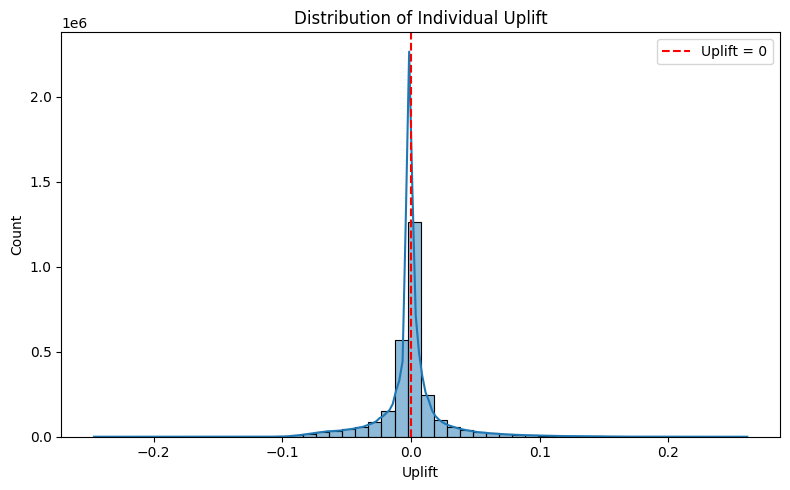

In [19]:
# Distribution of individual uplift
plt.figure(figsize=(8, 5))
sns.histplot(uplift_df["uplift"], bins=50, kde=True)

plt.axvline(0, color="red", linestyle="--", label="Uplift = 0")

plt.xlabel("Uplift")
plt.ylabel("Count")
plt.title("Distribution of Individual Uplift")
plt.legend()

plt.tight_layout()
plt.show()

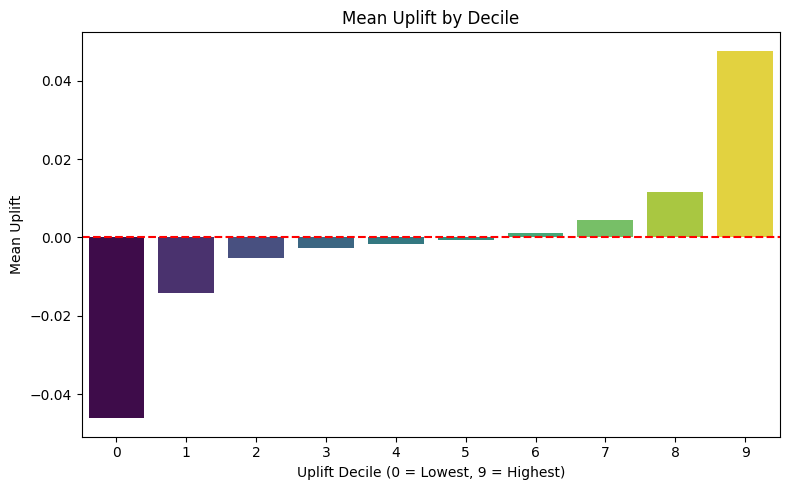

In [21]:
# Mean uplift by decile
decile_mean = uplift_df.groupby("uplift_decile")["uplift"].mean()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=decile_mean.index,
    y=decile_mean.values,
    hue=decile_mean.index,   # required for palette
    palette="viridis",
    legend=False
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Uplift Decile (0 = Lowest, 9 = Highest)")
plt.ylabel("Mean Uplift")
plt.title("Mean Uplift by Decile")

plt.tight_layout()
plt.show()